In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# READ THE SALARY DATASET & DISPLAY THE DATASET SHAPE
salary_data = pd.read_csv("C:\\Users\\Admin\\Documents\\arc_model_core\\ml_docs\\Datasets\\salary_records.csv")
print(f":> DATASET SHAPE: {salary_data.shape}")

display(salary_data)

:> DATASET SHAPE: (30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [2]:
# CHECK FOR MISSING VALUES IN THE DATASET
print(f":> TOTAL MISSING VALUES: {salary_data.isnull().sum().sum()}")

:> TOTAL MISSING VALUES: 0


In [3]:
# DISPLAY DATASET INFORMATION (DATA TYPES, NON-NULL COUNTS)
salary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [4]:
# DISPLAY SUMMARY STATISTICS OF THE DATASET
salary_data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


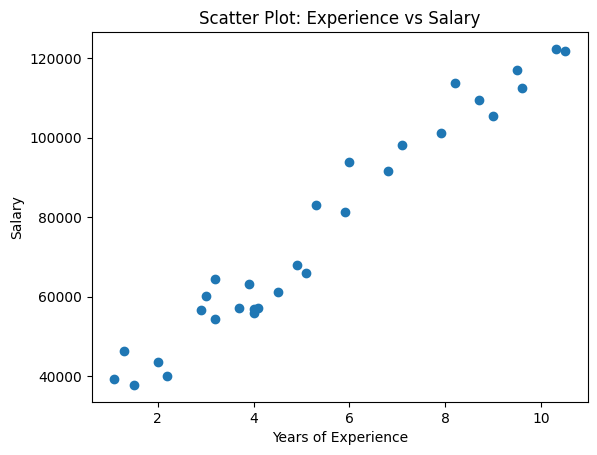

In [5]:
plt.scatter(salary_data['YearsExperience'], salary_data['Salary'])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Scatter Plot: Experience vs Salary")
plt.show()

In [6]:
# SEPARATE FEATURES (X) AND TARGET VARIABLE (y)
# NOTE: Typically we predict Salary from YearsExperience, but this dataset uses Salary as feature
X = salary_data[['Salary']]
y = salary_data["YearsExperience"]


# DISPLAY THE SHAPES OF FEATURES AND TARGET
print(f":> FEATURES SHAPE (X): {X.shape}")
print(f":> TARGET SHAPE (y): {y.shape}")

:> FEATURES SHAPE (X): (30, 1)
:> TARGET SHAPE (y): (30,)


In [7]:
# SPLIT THE DATA INTO TRAINING AND TESTING SETS (80% TRAIN, 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


# DISPLAY THE SHAPES OF SPLIT DATASETS
print(f":> TRAINING FEATURES SHAPE (X_train): {X_train.shape}")
print(f":> TESTING FEATURES SHAPE (X_test) {X_test.shape}")
print(f":> TRAINING TARGET SHAPE (y_train): {y_train.shape}")
print(f":> TESTING TARGET SHAPE (y_test): {y_test.shape}")

:> TRAINING FEATURES SHAPE (X_train): (24, 1)
:> TESTING FEATURES SHAPE (X_test) (6, 1)
:> TRAINING TARGET SHAPE (y_train): (24,)
:> TESTING TARGET SHAPE (y_test): (6,)


In [8]:
# INITIALIZE STANDARD SCALER FOR FEATURE NORMALIZATION
scaler = StandardScaler()

# INITIALIZE LINEAR REGRESSION MODEL
linear = LinearRegression()


# APPLY STANDARD SCALING TO TRAINING AND TEST DATA
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

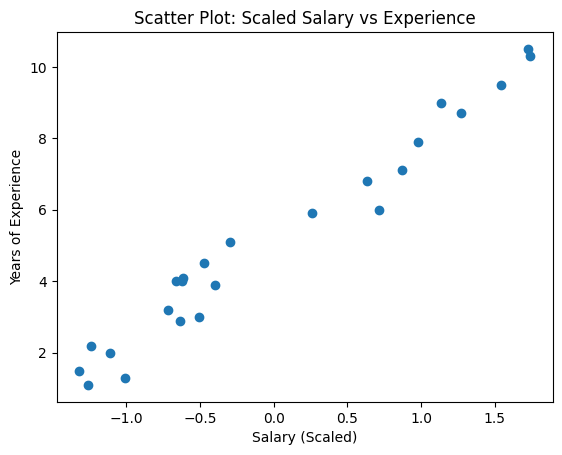

In [9]:
# VISUALIZE SCALED TRAINING DATA
plt.scatter(X_train, y_train)
plt.xlabel("Salary (Scaled)")
plt.ylabel("Years of Experience")
plt.title("Scatter Plot: Scaled Salary vs Experience")
plt.show()

In [10]:
# TRANSFORM A NEW VALUE (80) USING THE FITTED SCALER
salary_80_scaled = scaler.transform([[80]])
print(f":> SCALED VALUE FOR SALARY 80: {salary_80_scaled[0][0]:.4f}")

:> SCALED VALUE FOR SALARY 80: -2.6813


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
# TRAIN THE LINEAR REGRESSION MODEL ON SCALED DATA
linear.fit(X_train, y_train)


# DISPLAY THE MODEL PARAMETERS
print(f"=>> MODEL PARAMETERS >>")
print(f":> INTERCEPT (B0): {linear.intercept_:.4f}")
print(f":> COEFFICIENT (B1) 1D ARRAY: {linear.coef_[0]:.4f}")

=>> MODEL PARAMETERS >>
:> INTERCEPT (B0): 5.1875
:> COEFFICIENT (B1) 1D ARRAY: 2.8296


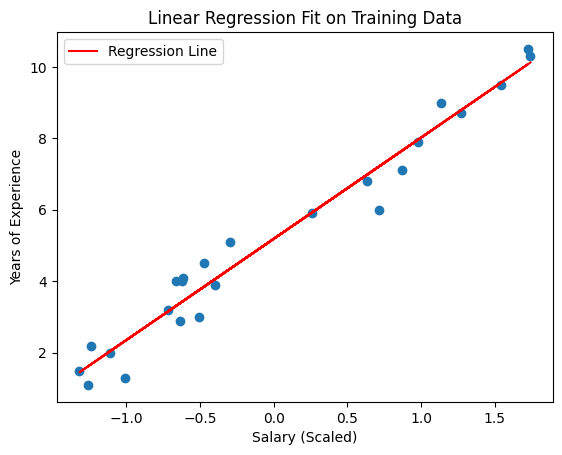

In [12]:
# VISUALIZE THE REGRESSION LINE ON TRAINING DATA
plt.scatter(X_train, y_train)
plt.plot(X_train, linear.predict(X_train), "r", label="Regression Line")
plt.xlabel("Salary (Scaled)")
plt.ylabel("Years of Experience")
plt.title("Linear Regression Fit on Training Data")
plt.legend()
plt.show()

In [13]:
# MAKE PREDICTIONS ON THE TEST SET
y_test_predicted = linear.predict(X_test)
y_test_predicted

array([9.12059345, 4.54579546, 9.24106098, 6.09641831, 4.18828222,
       3.44562087])

In [14]:
# DISPLAY ACTUAL VS PREDICTED VALUES
print("=>> PREDICTED YEARS OF EXPERIENCE (First 10) >>")
print(y_test_predicted[:10])

print("\n=>> ACTUAL YEARS OF EXPERIENCE (First 10) >>")
print(y_test[:10].values)

=>> PREDICTED YEARS OF EXPERIENCE (First 10) >>
[9.12059345 4.54579546 9.24106098 6.09641831 4.18828222 3.44562087]

=>> ACTUAL YEARS OF EXPERIENCE (First 10) >>
[9.6 4.9 8.2 5.3 3.2 3.7]


In [15]:
# CALCULATE EVALUATION METRICS
mse = mean_squared_error(y_test, y_test_predicted)
mae = mean_absolute_error(y_test, y_test_predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_predicted)


# CALCULATE ADJUSTED R-SQUARED
n = len(y_test)
k = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

In [16]:
# DISPLAY THE EVALUATION METRICS
print("=" * 50)
print("=>> MODEL EVALUATION METRICS >>")
print("=" * 50)
print(f":> MEAN SQUARED ERROR (MSE): {mse:.4f}")
print(f":> MEAN ABSOLUTE ERROR (MAE): {mae:.4f}")
print(f":> ROOT MEAN SQUARED ERROR (RMSE): {rmse:.4f}")
print(f":> R-SQUARED SCORE (R²): {r2:.4f}")
print(f":> ADJUSTED R-SQUARED SCORE: {adjusted_r2:.4f}")
print("=" * 50)

=>> MODEL EVALUATION METRICS >>
:> MEAN SQUARED ERROR (MSE): 0.5191
:> MEAN ABSOLUTE ERROR (MAE): 0.6523
:> ROOT MEAN SQUARED ERROR (RMSE): 0.7205
:> R-SQUARED SCORE (R²): 0.9039
:> ADJUSTED R-SQUARED SCORE: 0.8799


In [17]:
# INTERPRET THE RESULTS
print("=>> MODEL INTERPRETATION >>")
print("=" * 50)

if r2 > 0.7:
    print(f":> ✓ R² Score ({r2:.4f}) indicates a strong relationship between Salary and Years of Experience")
elif r2 > 0.5:
    print(f":> ✓ R² Score ({r2:.4f}) indicates a moderate relationship between Salary and Years of Experience")
else:
    print(f":> ✗ R² Score ({r2:.4f}) indicates a weak relationship between Salary and Years of Experience")

=>> MODEL INTERPRETATION >>
:> ✓ R² Score (0.9039) indicates a strong relationship between Salary and Years of Experience
